In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Dataset 1: Iris
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=42)

# Initialize and train
clf_iris = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_iris.fit(X_train, y_train)

# Predict and Evaluate
y_pred = clf_iris.predict(X_test)
print('--- Iris Dataset Performance ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

--- Iris Dataset Performance ---
Accuracy: 0.9778
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.93      1.00      0.96        13
   virginica       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



In [ ]:
# Dataset 2: Wine
wine = load_wine()
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(wine.data, wine.target, test_size=0.3, random_state=42)

# Initialize and train
clf_wine = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_wine.fit(X_train_w, y_train_w)

# Predict and Evaluate
y_pred_w = clf_wine.predict(X_test_w)
print('--- Wine Dataset Performance ---')
print(f'Accuracy: {accuracy_score(y_test_w, y_pred_w):.4f}')
print(classification_report(y_test_w, y_pred_w, target_names=wine.target_names))

--- Wine Dataset Performance ---
Accuracy: 0.8519
              precision    recall  f1-score   support

     class_0       0.82      0.95      0.88        19
     class_1       0.89      0.81      0.85        21
     class_2       0.85      0.79      0.81        14

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54



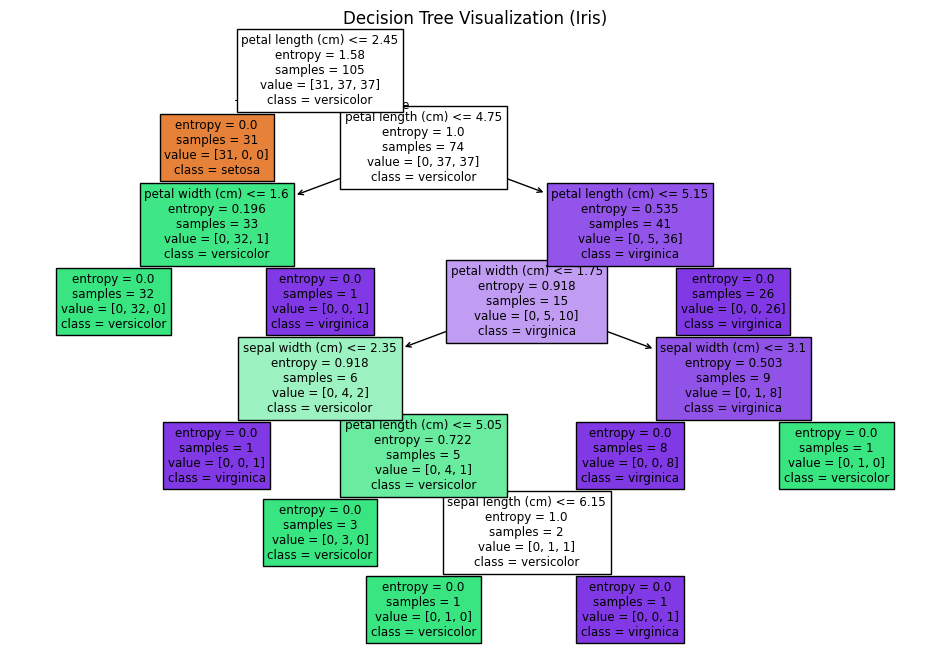

In [ ]:
# Visualizing the Iris Decision Tree
plt.figure(figsize=(12,8))
plot_tree(clf_iris, filled=True, feature_names=iris.feature_names, class_names=list(iris.target_names))
plt.title('Decision Tree Visualization (Iris)')
plt.show()

Accuracy on simple dataset: 100.00%


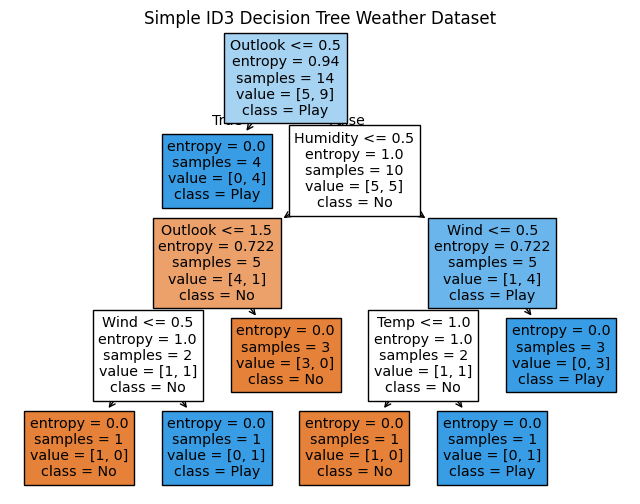

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Creating a classic simple dataset: Play Tennis
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temp': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)

# ID3 works with categorical data; we need to encode them for sklearn
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Play', axis=1)
y = df['Play']

# Train the model using Entropy (ID3 logic)
clf_simple = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_simple.fit(X, y)

# Accuracy on the training set itself (since it's a demonstration dataset)
y_pred = clf_simple.predict(X)
print(f'Accuracy on simple dataset: {accuracy_score(y, y_pred)*100:.2f}%')

# Visualization
plt.figure(figsize=(8,6))
plot_tree(clf_simple,
          feature_names=['Outlook', 'Temp', 'Humidity', 'Wind'],
          class_names=['No', 'Play'],
          filled=True)
plt.title('Simple ID3 Decision Tree Weather Dataset')
plt.show()

Accuracy (CART - Entropy) on simple dataset: 100.00%


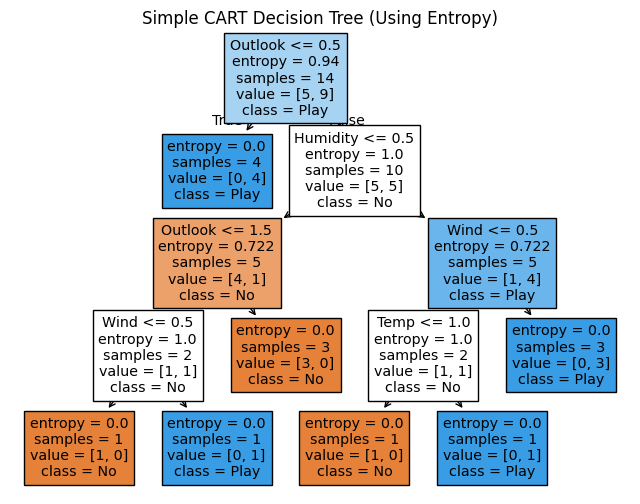

In [ ]:
# Training the model using CART logic but avoiding Gini Impurity
# We use criterion='entropy' as requested
clf_cart = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_cart.fit(X, y)

# Accuracy
y_pred_cart = clf_cart.predict(X)
print(f'Accuracy (CART - Entropy) on simple dataset: {accuracy_score(y, y_pred_cart)*100:.2f}%')

# Visualization
plt.figure(figsize=(8,6))
plot_tree(clf_cart,
          feature_names=['Outlook', 'Temp', 'Humidity', 'Wind'],
          class_names=['No', 'Play'],
          filled=True)
plt.title('Simple CART Decision Tree (Using Entropy)')
plt.show()

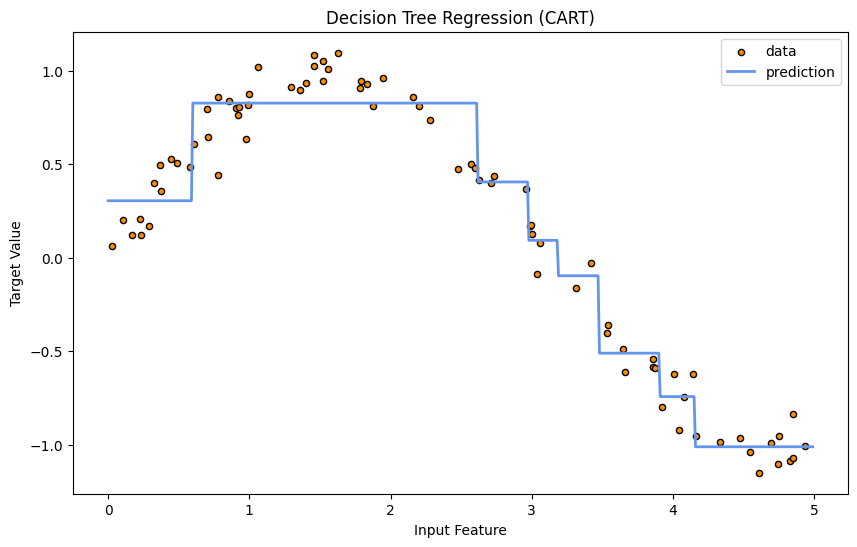

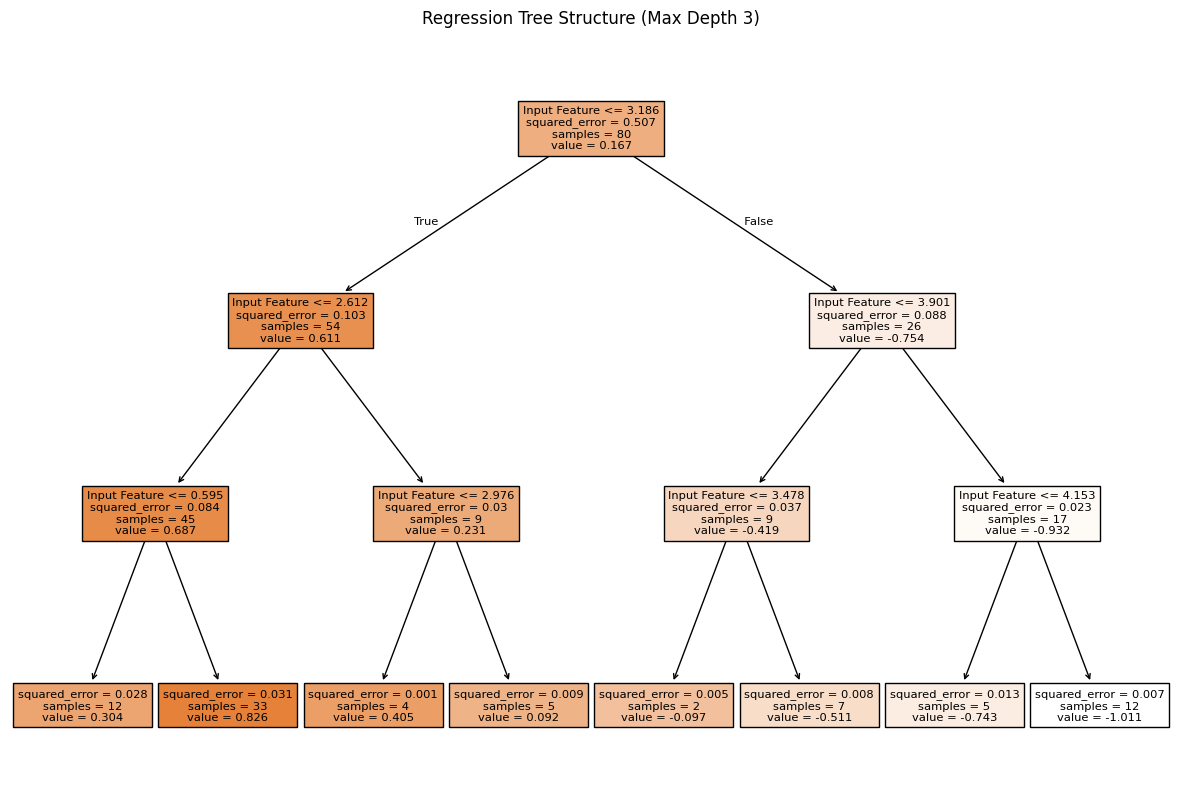

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# 1. Create a simple synthetic dataset
np.random.seed(42)
X_reg = np.sort(5 * np.random.rand(80, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.1, X_reg.shape[0])

# 2. Initialize and train the CART Regressor
# We'll limit max_depth so the tree remains easy to understand
regressor = DecisionTreeRegressor(max_depth=3)
regressor.fit(X_reg, y_reg)

# 3. Predict
X_test_reg = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_pred_reg = regressor.predict(X_test_reg)

# 4. Visualize the Regression Results
plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test_reg, y_pred_reg, color="cornflowerblue", label="prediction", linewidth=2)
plt.xlabel("Input Feature")
plt.ylabel("Target Value")
plt.title("Decision Tree Regression (CART)")
plt.legend()
plt.show()

# 5. Visualize the Tree Structure
plt.figure(figsize=(15, 10))
plot_tree(regressor, filled=True, feature_names=['Input Feature'])
plt.title("Regression Tree Structure (Max Depth 3)")
plt.show()